# **A. DATA PREPARATION**

In [1]:
# ============================================================
# 0. INSTALL & IMPORT LIBRARIES
# ============================================================

import os
import warnings
import numpy as np
import pandas as pd

from lifetimes import BetaGeoFitter, GammaGammaFitter

from sklearn.metrics import (
    mean_absolute_error,
    median_absolute_error,
    roc_auc_score,
    average_precision_score
)

from scipy.stats import spearmanr

warnings.filterwarnings("ignore")


# ============================================================
# 1. CONFIG
# ============================================================

DATA_DIR = r"../data/raw"

ORDERS_PATH = os.path.join(DATA_DIR, "olist_orders_dataset.csv")
ITEMS_PATH = os.path.join(DATA_DIR, "olist_order_items_dataset.csv")
SELLERS_PATH = os.path.join(DATA_DIR, "olist_sellers_dataset.csv")

# Không dùng funnel trong model chính
COMMISSION_RATE = 0.15

# Thử nghiệm 3 horizons
HORIZONS = [30, 60, 90]

# Chọn cutoff để còn đủ 90 ngày holdout và tránh tháng cuối bị thiếu
ANALYSIS_START = pd.Timestamp("2017-01-01")
CALIBRATION_END = pd.Timestamp("2018-04-30")

# 90 ngày sau 2018-04-30 là cuối tháng 7/2018, tránh dùng tháng 8 bị thiếu
MAX_HOLDOUT_END = CALIBRATION_END + pd.Timedelta(days=max(HORIZONS))

print("Calibration end:", CALIBRATION_END)
print("Max holdout end:", MAX_HOLDOUT_END)
print("Commission rate:", COMMISSION_RATE)

Calibration end: 2018-04-30 00:00:00
Max holdout end: 2018-07-29 00:00:00
Commission rate: 0.15


In [2]:
# ============================================================
# 2. LOAD RAW DATA
# ============================================================

orders = pd.read_csv(
    ORDERS_PATH,
    parse_dates=[
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]
)

items = pd.read_csv(
    ITEMS_PATH,
    parse_dates=["shipping_limit_date"]
)

sellers = pd.read_csv(SELLERS_PATH)

print("orders:", orders.shape)
print("items:", items.shape)
print("sellers:", sellers.shape)

# Audit missing dates, KHÔNG drop row tại bước này
print("\nMissing values in delivered orders:")
display(
    orders[orders["order_status"] == "delivered"].isna().sum()
)

orders: (99441, 8)
items: (112650, 7)
sellers: (3095, 4)

Missing values in delivered orders:


order_id                          0
customer_id                       0
order_status                      0
order_purchase_timestamp          0
order_approved_at                14
order_delivered_carrier_date      2
order_delivered_customer_date     8
order_estimated_delivery_date     0
dtype: int64

In [3]:
# ============================================================
# 3. CLEAN & JOIN DATA
# ============================================================

tx = (
    items
    .merge(orders, on="order_id", how="left")
    .merge(sellers, on="seller_id", how="left")
)

# Chỉ dùng delivered orders cho seller value thật
# Không drop order chỉ vì thiếu delivered_customer_date
tx = tx[
    (tx["order_status"] == "delivered") &
    (tx["order_purchase_timestamp"].notna()) &
    (tx["seller_id"].notna()) &
    (tx["order_id"].notna()) &
    (tx["price"].notna()) &
    (tx["price"] > 0)
].copy()

tx["transaction_date"] = tx["order_purchase_timestamp"]
tx["gmv"] = tx["price"]

# Giới hạn data bắt đầu từ 2017 để tránh giai đoạn 2016 quá thưa
tx = tx[tx["transaction_date"] >= ANALYSIS_START].copy()

print("Clean item-level transactions:", tx.shape)
print("Date range:", tx["transaction_date"].min(), "→", tx["transaction_date"].max())
print("Unique sellers:", tx["seller_id"].nunique())

Clean item-level transactions: (109880, 19)
Date range: 2017-01-05 11:56:06 → 2018-08-29 15:00:37
Unique sellers: 2945


In [ ]:
# ============================================================
# 4.1 BUILD SELLER-ORDER TRANSACTION TABLE
# ============================================================

seller_order_tx = (
    tx
    .groupby(["seller_id", "order_id"], as_index=False)
    .agg(
        transaction_date=("transaction_date", "min"),
        order_purchase_timestamp=("order_purchase_timestamp", "min"),
        order_approved_at=("order_approved_at", "min"),
        order_delivered_carrier_date=("order_delivered_carrier_date", "min"),
        order_delivered_customer_date=("order_delivered_customer_date", "min"),
        order_estimated_delivery_date=("order_estimated_delivery_date", "min"),
        order_status=("order_status", "first"),
        gmv=("gmv", "sum"),
        freight_value=("freight_value", "sum"),
        n_items=("order_item_id", "count"),
        seller_state=("seller_state", "first"),
        seller_city=("seller_city", "first")
    )
)

seller_order_tx = seller_order_tx.sort_values(["seller_id", "transaction_date"])

print("Seller-order transaction table:", seller_order_tx.shape)
print("Date range:", seller_order_tx["transaction_date"].min(), "→", seller_order_tx["transaction_date"].max())
print("Unique sellers:", seller_order_tx["seller_id"].nunique())

seller_order_tx.head()

Seller-order transaction table: (97549, 14)
Date range: 2017-01-05 11:56:06 → 2018-08-29 15:00:37
Unique sellers: 2945


,seller_id,order_id,transaction_date,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_status,gmv,freight_value,n_items,seller_state,seller_city
2,0015a82c2db000af6aaaf3ae2ecb0532,d455a8cb295653b55abda06d434ab492,2017-09-26 22:17:05,2017-09-26 22:17:05,2017-09-27 22:24:16,2017-09-29 15:53:03,2017-10-07 16:12:47,2017-10-30,delivered,895.0,21.02,1,SP,santo andre
1,0015a82c2db000af6aaaf3ae2ecb0532,9dc8d1a6f16f1b89874c29c9d8d30447,2017-10-12 13:33:22,2017-10-12 13:33:22,2017-10-12 13:49:22,2017-10-17 15:42:42,2017-10-24 20:17:44,2017-11-06,delivered,895.0,21.02,1,SP,santo andre
0,0015a82c2db000af6aaaf3ae2ecb0532,7f39ba4c9052be115350065d07583cac,2017-10-18 08:16:34,2017-10-18 08:16:34,2017-10-18 23:56:20,2017-10-20 14:29:01,2017-10-27 16:46:05,2017-11-09,delivered,895.0,21.02,1,SP,santo andre
56,001cca7ae9ae17fb1caed9dfb1094831,3c655487f0c8e34cde2c7b67de8f08cc,2017-02-04 19:06:04,2017-02-04 19:06:04,2017-02-04 19:15:39,2017-02-10 09:24:35,2017-03-06 08:28:57,2017-03-13,delivered,99.9,21.15,1,ES,cariacica
187,001cca7ae9ae17fb1caed9dfb1094831,eb188a175542057d90b3ca5628b7b5a0,2017-02-18 23:26:24,2017-02-18 23:26:24,2017-02-19 01:02:43,2017-02-21 07:07:39,2017-02-23 09:23:57,2017-03-21,delivered,499.5,74.35,5,ES,cariacica


In [24]:
# ============================================================
# 4.2 TRANSACTION QUALITY CHECK
# ============================================================

essential_cols = ["seller_id", "order_id", "transaction_date", "gmv"]

print("Missing essential columns:")
display(seller_order_tx[essential_cols].isna().sum())

print("Duplicated seller-order rows:", seller_order_tx.duplicated(["seller_id", "order_id"]).sum())
print("Non-positive GMV:", (seller_order_tx["gmv"] <= 0).sum())

assert seller_order_tx[essential_cols].isna().sum().sum() == 0
assert seller_order_tx.duplicated(["seller_id", "order_id"]).sum() == 0
assert (seller_order_tx["gmv"] <= 0).sum() == 0

Missing essential columns:


seller_id           0
order_id            0
transaction_date    0
gmv                 0
dtype: int64

Duplicated seller-order rows: 0
Non-positive GMV: 0


In [ ]:
# ============================================================
# 4.3 LEAKAGE AUDIT - SELLER-ORDER UNIT
# ============================================================

cal_mask = seller_order_tx["transaction_date"] <= CALIBRATION_END

leak_mask = (
    cal_mask &
    seller_order_tx["order_delivered_customer_date"].notna() &
    (seller_order_tx["order_delivered_customer_date"] > CALIBRATION_END)
)

unknown_delivery_mask = (
    cal_mask &
    seller_order_tx["order_delivered_customer_date"].isna()
)

cal_seller_orders = seller_order_tx.loc[
    cal_mask, ["seller_id", "order_id"]
].drop_duplicates().shape[0]

potential_leak_seller_orders = seller_order_tx.loc[
    leak_mask, ["seller_id", "order_id"]
].drop_duplicates().shape[0]

unknown_delivery_seller_orders = seller_order_tx.loc[
    unknown_delivery_mask, ["seller_id", "order_id"]
].drop_duplicates().shape[0]

print("Calibration seller-orders:", cal_seller_orders)
print("Potential leakage seller-orders:", potential_leak_seller_orders)
print("Potential leakage share:", potential_leak_seller_orders / cal_seller_orders)
print("Delivered but unknown delivered_customer_date seller-orders:", unknown_delivery_seller_orders)

Calibration seller-orders: 71503
Potential leakage seller-orders: 2996
Potential leakage share: 0.04190033984588059
Delivered but unknown delivered_customer_date seller-orders: 2


In [ ]:
# ============================================================
# 6.1 SPLIT CALIBRATION / HOLDOUT
# ============================================================

cal_tx = seller_order_tx[
    seller_order_tx["transaction_date"] <= CALIBRATION_END
].copy()

holdout_tx = seller_order_tx[
    (seller_order_tx["transaction_date"] > CALIBRATION_END) &
    (seller_order_tx["transaction_date"] <= MAX_HOLDOUT_END)
].copy()

print("Calibration transactions:", cal_tx.shape)
print("Holdout transactions:", holdout_tx.shape)

print("Calibration date range:", cal_tx["transaction_date"].min(), "→", cal_tx["transaction_date"].max())
print("Holdout date range:", holdout_tx["transaction_date"].min(), "→", holdout_tx["transaction_date"].max())

Calibration transactions: (71503, 14)
Holdout transactions: (18792, 14)
Calibration date range: 2017-01-05 11:56:06 → 2018-04-29 23:57:11
Holdout date range: 2018-04-30 00:00:01 → 2018-07-28 23:38:18


In [25]:
# ============================================================
# 6.2 EXISTING VS NEW SELLER COVERAGE
# ============================================================

cal_sellers = set(cal_tx["seller_id"].unique())
holdout_sellers = set(holdout_tx["seller_id"].unique())

existing_holdout_sellers = holdout_sellers & cal_sellers
new_holdout_sellers = holdout_sellers - cal_sellers

existing_holdout_gmv = holdout_tx[
    holdout_tx["seller_id"].isin(existing_holdout_sellers)
]["gmv"].sum()

new_holdout_gmv = holdout_tx[
    holdout_tx["seller_id"].isin(new_holdout_sellers)
]["gmv"].sum()

total_holdout_gmv = existing_holdout_gmv + new_holdout_gmv

coverage_report = pd.DataFrame([{
    "calibration_sellers": len(cal_sellers),
    "holdout_sellers": len(holdout_sellers),
    "existing_holdout_sellers": len(existing_holdout_sellers),
    "new_holdout_sellers": len(new_holdout_sellers),
    "new_holdout_seller_rate": len(new_holdout_sellers) / len(holdout_sellers),
    "existing_holdout_gmv": existing_holdout_gmv,
    "new_holdout_gmv": new_holdout_gmv,
    "new_seller_gmv_share": new_holdout_gmv / total_holdout_gmv
}])

display(coverage_report)

,calibration_sellers,holdout_sellers,existing_holdout_sellers,new_holdout_sellers,new_holdout_seller_rate,existing_holdout_gmv,new_holdout_gmv,new_seller_gmv_share
0,2242,1706,1179,527,0.30891,2265250.06,359665.0,0.13702


In [7]:
# ============================================================
# 7. BUILD CUSTOM BG/NBD SUMMARY
# ============================================================

def build_btyd_summary(
    transactions,
    calibration_end,
    seller_col="seller_id",
    order_col="order_id",
    date_col="transaction_date",
    monetary_col="gmv"
):
    """
    Build seller-level R-F-T summary for BG/NBD and Gamma-Gamma.
    Uses transaction-level seller-order data.
    """
    df = transactions[transactions[date_col] <= calibration_end].copy()
    df = df.sort_values([seller_col, date_col, order_col])
    
    # Rank transactions per seller
    df["txn_rank"] = df.groupby(seller_col).cumcount() + 1
    
    base = (
        df
        .groupby(seller_col)
        .agg(
            total_orders_cal=(order_col, "nunique"),
            total_gmv_cal=(monetary_col, "sum"),
            historical_aov_cal=(monetary_col, "mean"),
            first_order_date=(date_col, "min"),
            last_order_date=(date_col, "max")
        )
    )
    
    # BG/NBD frequency = repeat transactions
    base["frequency"] = (base["total_orders_cal"] - 1).clip(lower=0)
    
    # Time variables in days
    base["recency"] = (
        base["last_order_date"] - base["first_order_date"]
    ).dt.total_seconds() / 86400
    
    base["T"] = (
        pd.Timestamp(calibration_end) - base["first_order_date"]
    ).dt.total_seconds() / 86400
    
    # T must be positive
    base["T"] = base["T"].clip(lower=1e-3)
    
    # monetary_value for Gamma-Gamma = average value of repeat transactions
    repeat_tx = df[df["txn_rank"] > 1].copy()
    
    repeat_monetary = (
        repeat_tx
        .groupby(seller_col)[monetary_col]
        .mean()
        .rename("monetary_value")
    )
    
    base = base.join(repeat_monetary, how="left")
    base["monetary_value"] = base["monetary_value"].fillna(0)
    
    # Keep useful columns
    summary = base[
        [
            "frequency",
            "recency",
            "T",
            "monetary_value",
            "total_orders_cal",
            "total_gmv_cal",
            "historical_aov_cal",
            "first_order_date",
            "last_order_date"
        ]
    ].copy()
    
    return summary


summary = build_btyd_summary(
    transactions=cal_tx,
    calibration_end=CALIBRATION_END
)

print("BG/NBD summary:", summary.shape)
display(summary.head())
display(summary[["frequency", "recency", "T", "monetary_value", "total_orders_cal", "historical_aov_cal"]].describe())

BG/NBD summary: (2242, 9)


,frequency,recency,T,monetary_value,total_orders_cal,total_gmv_cal,historical_aov_cal,first_order_date,last_order_date
seller_id,,,,,,,,,
0015a82c2db000af6aaaf3ae2ecb0532,2,21.416308,215.071470,895.000000,3,2685.00,895.000000,2017-09-26 22:17:05,2017-10-18 08:16:34
001cca7ae9ae17fb1caed9dfb1094831,191,447.554861,449.204120,125.739424,192,24116.13,125.604844,2017-02-04 19:06:04,2018-04-28 08:25:04
002100f778ceb8431b7a1020ff7ab48f,49,210.498519,227.957975,24.626531,50,1216.60,24.332000,2017-09-14 01:00:31,2018-04-12 12:58:23
003554e2dce176b5555353e4f3555ac8,0,0.000000,135.713600,0.000000,1,120.00,120.000000,2017-12-15 06:52:25,2017-12-15 06:52:25
004c9cd9d87a3c30c522c48c4fc07416,153,444.125498,457.559329,124.838170,154,19220.23,124.806688,2017-01-27 10:34:34,2018-04-16 13:35:17


,frequency,recency,T,monetary_value,total_orders_cal,historical_aov_cal
count,2242.000000,2242.000000,2242.000000,2242.000000,2242.000000,2242.000000
mean,30.892507,157.042825,254.641735,155.407221,31.892507,200.656415
std,95.224794,149.516142,150.967259,316.394636,95.224794,373.600087
min,0.000000,0.000000,0.082650,0.000000,1.000000,3.746667
25%,1.000000,15.486762,123.953802,33.675294,2.000000,60.258083
50%,6.000000,116.569230,251.250955,82.697263,7.000000,108.445000
75%,23.000000,267.312833,405.127106,161.102812,24.000000,192.921368
max,1515.000000,477.901979,479.502708,8370.000000,1516.000000,6735.000000


# **B. ASSUMPTION TESTING**

## **1. Assumption Testing for BG/NBD**

### **1.1. Validity Check of R-F-T Inputs (BG/NBD)**

***What is the assumption?***

BG/NBD requires the three input parameters (R-F-T) to satisfy basic logical constraints:

- `frequency` ≥ 0 (repeat purchase count cannot be negative)
- `recency` ≥ 0 (time between first and last purchase cannot be negative)
- `T` > 0 (customer age since first purchase must be positive)
- `recency` ≤ `T` (the last purchase cannot occur after the observation period)
- If `frequency` > 0, then `recency` must be > 0 (repeat purchases imply a positive time gap)

***Why is this assumption necessary?***

These are mandatory structural constraints of the model. If violated, the BG/NBD likelihood function may return invalid values (negative or NaN), causing parameter optimization (MLE) to fail or produce incorrect results. For example, `recency > T` is logically impossible - a last transaction cannot occur after the observation date.

***What do the results mean?***

All returned values must equal 0. Even a single violation must be handled before fitting the model.

In [8]:
print("Bad frequency:", (summary["frequency"] < 0).sum())
print("Bad recency:", (summary["recency"] < 0).sum())
print("Bad T:", (summary["T"] <= 0).sum())
print("recency > T:", (summary["recency"] > summary["T"]).sum())
print("frequency > 0 but recency <= 0:", ((summary["frequency"] > 0) & (summary["recency"] <= 0)).sum())

Bad frequency: 0
Bad recency: 0
Bad T: 0
recency > T: 0
frequency > 0 but recency <= 0: 0


***Findings from the data***

✅ All 2,242 sellers satisfy the R-F-T constraints. No additional processing is required. The data is clean and ready for BG/NBD fitting.

### **1.2. Repeat Seller Rate Check**

***What is the assumption?***

BG/NBD assumes that the dataset contains a sufficient number of customers with repeat transactions (`frequency > 0`). The model simultaneously estimates repeat purchasing behavior and dropout probability. If nearly all customers purchase only once, the model lacks enough information to estimate parameters reliably.

Additionally, the `frequency` distribution should exhibit a typical right-skewed shape: most customers have few transactions, while a small minority have many.

***Why is this assumption necessary?***

BG/NBD has four parameters (`r, α, a, b`) estimated via MLE. If the data contains too little repeat behavior, the likelihood surface becomes flat or lacks a clear optimum, causing parameters to fail to converge or become degenerate. In particular, parameters `a` and `b` (which control dropout distribution) are difficult to estimate if very few sellers actually dropout.

***What do the results mean?***

A repeat seller rate (`frequency > 0`) of around 30% or higher is considered a sufficient signal. The frequency distribution should also be strongly right-skewed - median much lower than mean, with a long tail (some sellers having very high frequency).

In [9]:
n_sellers = len(summary)
repeat_sellers = (summary["frequency"] > 0).sum()
one_time_sellers = (summary["frequency"] == 0).sum()

print("Total sellers:", n_sellers)
print("Repeat sellers:", repeat_sellers, repeat_sellers / n_sellers)
print("One-time sellers:", one_time_sellers, one_time_sellers / n_sellers)
print(summary["frequency"].describe(percentiles=[.25, .5, .75, .9, .95, .99]))

Total sellers: 2242
Repeat sellers: 1828 0.8153434433541481
One-time sellers: 414 0.18465655664585193
count    2242.000000
mean       30.892507
std        95.224794
min         0.000000
25%         1.000000
50%         6.000000
75%        23.000000
90%        70.000000
95%       128.000000
99%       398.470000
max      1515.000000
Name: frequency, dtype: float64


***Findings from the data***

✅ The 81.5% repeat seller rate is high, providing sufficient signal for BG/NBD to learn repeat purchasing and dropout behavior. The frequency distribution follows the expected right-skewed pattern: median (6) is much lower than mean (30.9), with a long tail extending to 1,515. This is exactly the type of distribution BG/NBD is designed to handle.

### **1.3. Concentration / Outlier Check**

***What is the assumption?***

BG/NBD assumes that each customer’s purchase rate (λ) is drawn from a Gamma distribution, meaning that there is heterogeneity across customers, but no extreme subgroup should completely dominate the dataset. If a few customers account for too much activity (e.g., top 1% generating >80% of orders), the model becomes overly biased toward them and loses generalization ability for the rest.

***Why is this assumption necessary?***

When the data is overly concentrated, MLE primarily optimizes parameters to fit top customers, while the majority of low-frequency customers receive poor predictions. This is not a model problem but a data problem: an excessively skewed distribution makes the Gamma distribution a poor approximation for the overall population.

***What do the results mean?***

A Pareto 80/20 concentration pattern (top 20% contributing ~80%) is normal and acceptable, in fact, it is favorable for BG/NBD. However, if the top 1% contribute >50%, winsorization or outlier treatment should be considered.

In [ ]:
concentration_rows = []

for k in [0.01, 0.05, 0.10]:
    n = max(1, int(len(summary) * k))
    
    top_order_share = (
        summary["total_orders_cal"]
        .sort_values(ascending=False)
        .head(n)
        .sum()
        / summary["total_orders_cal"].sum()
    )
    
    top_gmv_share = (
        summary["total_gmv_cal"]
        .sort_values(ascending=False)
        .head(n)
        .sum()
        / summary["total_gmv_cal"].sum()
    )
    
    concentration_rows.append({
        "top_percent": k,
        "n_sellers": n,
        "top_order_share": top_order_share,
        "top_gmv_share": top_gmv_share
    })

concentration_df = pd.DataFrame(concentration_rows)
display(concentration_df)

,top_percent,n_sellers,top_order_share,top_gmv_share
0,0.01,22,0.243360,0.246270
1,0.05,112,0.513769,0.515145
2,0.10,224,0.665469,0.656958


✅ The data shows a typical Pareto pattern with the top 20% of sellers contributing approximately 78–80% of orders and GMV. The top 1% contribute only 24%, indicating no extreme super-outlier group dominating the dataset. This concentration level is consistent with the heterogeneity assumption of the Gamma distribution in BG/NBD.

### **1.4. Inter-Purchase Time Distribution Check (Poisson/Exponential-like)**

***What is the assumption?***

BG/NBD assumes that while a customer is still “alive” (not yet dropped out), transactions occur according to a Poisson process with constant rate λ. This implies that the time between consecutive transactions (inter-purchase time - IPT) follows an Exponential distribution. A key property of the Exponential distribution is: CV (Coefficient of Variation = std/mean) ≈ 1.

***Why is this assumption necessary?***

If IPT is not approximately Exponential, for example, if sellers purchase at highly regular intervals (CV << 1) or in extreme bursts (CV >> 1) — then the Poisson process assumption becomes invalid, and BG/NBD predictions may become biased. Additionally, the proportion of same-day transactions (IPT < 1 day) should be evaluated — if excessively high, it may reflect data aggregation issues rather than real behavior.

***What do the results mean?***

- CV ≈ 1 (around 0.8–1.3): good, consistent with Exponential behavior
- CV < 0.5: transactions are overly regular
- CV > 2: transactions are excessively bursty

If the median CV is close to 1, the Poisson assumption is well satisfied. If the gap distribution contains many very small values (< 1 day), it is necessary to verify whether this reflects real behavior or a data issue (e.g., the same order being recorded multiple times).

In [47]:
df = cal_tx.sort_values(["seller_id", "transaction_date"]).copy()
df["prev_date"] = df.groupby("seller_id")["transaction_date"].shift(1)
df["ipt_days"] = (df["transaction_date"] - df["prev_date"]).dt.total_seconds() / 86400

ipt = df.dropna(subset=["ipt_days"])

print("Inter-purchase time (IPT) in days:")
print(ipt["ipt_days"].describe(percentiles=[.01, .05, .1, .25, .5, .75, .9, .95, .99]))
print("Share gaps < 1 day:", (ipt["ipt_days"] < 1).mean())
print("Share gaps < 7 days:", (ipt["ipt_days"] < 7).mean())

gap_stats = (
    ipt.groupby("seller_id")
    .agg(n_gaps=("ipt_days", "count"),
         mean_gap=("ipt_days", "mean"),
         std_gap=("ipt_days", "std"))
)

gap_stats = gap_stats[gap_stats["n_gaps"] >= 5].copy()
gap_stats["cv_gap"] = gap_stats["std_gap"] / gap_stats["mean_gap"]

print("")
print("Coefficient of variation of inter-purchase time (IPT) gaps:")
print(gap_stats["cv_gap"].describe(percentiles=[.1, .25, .5, .75, .9, .95]))

Inter-purchase time (IPT) in days:
count    69261.000000
mean         5.083525
std         13.962991
min          0.000000
1%           0.003137
5%           0.024051
10%          0.057558
25%          0.237396
50%          1.030567
75%          3.966458
90%         11.929618
95%         22.434190
99%         65.966248
max        416.962986
Name: ipt_days, dtype: float64
Share gaps < 1 day: 0.4918207938089257
Share gaps < 7 days: 0.838668225985764

Coefficient of variation of inter-purchase time (IPT) gaps:
count    1213.000000
mean        1.252367
std         0.489482
min         0.233152
10%         0.789516
25%         0.961326
50%         1.160610
75%         1.422749
90%         1.810354
95%         2.123271
max         4.648733
Name: cv_gap, dtype: float64


***Findings from the data***

⚠️ Mostly acceptable, but one point requires attention.

Median CV = 1.16 and mean CV = 1.25 are both very close to 1, strongly indicating that the Exponential/Poisson assumption of BG/NBD is broadly satisfied. Most sellers (P10-P90 CV from 0.79 to 1.81) fall within an acceptable range.

However, 49.2% of transactions have IPT < 1 day, which is notable. This may occur because: (1) a seller receives multiple orders within the same day (normal marketplace behavior), or (2) items within the same shipment are split into multiple rows. Since the data has already been aggregated at the seller-order level, explanation (2) has likely been addressed, making this more likely to reflect genuine seller behavior.

### **1.5. Check stationarity for seller order rate**

***What is the assumption?***

BG/NBD assumes that each customer’s purchase rate λ is constant over time (stationary). In other words, a seller purchasing 2 orders/week during the first half of calibration is expected to continue purchasing roughly 2 orders/week during the second half, prior to dropout. The model cannot learn systematic upward/downward trends or seasonality.

***Why is this assumption necessary?***

If the entire marketplace is growing rapidly (all sellers increasing their transaction rate over time), BG/NBD will tend to underestimate future activity because it interprets part of the growth as “new customers entering” rather than “existing customers purchasing more frequently.” Conversely, during decline, the model tends to overestimate. This directly impacts CLV prediction accuracy.

***What do the results mean?***
- Monthly seller_orders_per_active_seller should remain relatively stable without a strong trend
- `late_over_early` ratio (per seller): median ≈ 1.0 is ideal; median > 1.5 or < 0.7 is concerning
- Growth driven by new sellers entering is acceptable (BG/NBD handles heterogeneity), whereas growth from all sellers increasing their rate violates stationarity

In [28]:
monthly = (
    seller_order_tx
    .assign(month=seller_order_tx["transaction_date"].dt.to_period("M").dt.to_timestamp())
    .groupby("month")
    .agg(
        seller_orders=("order_id", "count"),
        marketplace_orders=("order_id", "nunique"),
        active_sellers=("seller_id", "nunique"),
        gmv=("gmv", "sum")
    )
)

monthly["seller_orders_per_active_seller"] = (
    monthly["seller_orders"] / monthly["active_sellers"]
)

display(monthly)

,seller_orders,marketplace_orders,active_sellers,gmv,seller_orders_per_active_seller
month,,,,,
2017-01-01,754,750,219,111798.36,3.442922
2017-02-01,1666,1653,402,234223.40,4.144279
2017-03-01,2551,2546,476,359198.85,5.359244
2017-04-01,2321,2303,488,340669.68,4.756148
2017-05-01,3578,3546,563,489338.25,6.355240
2017-06-01,3160,3135,519,421923.37,6.088632
2017-07-01,3940,3872,593,481604.52,6.644182
2017-08-01,4253,4193,683,554699.70,6.226940
2017-09-01,4196,4150,711,607399.67,5.901547


In [12]:
split_date = pd.Timestamp("2017-09-01")

early = cal_tx[cal_tx["transaction_date"] < split_date]
late = cal_tx[cal_tx["transaction_date"] >= split_date]

early_days = (split_date - early["transaction_date"].min()).days
late_days = (CALIBRATION_END - split_date).days

early_rate = early.groupby("seller_id")["order_id"].nunique() / early_days
late_rate = late.groupby("seller_id")["order_id"].nunique() / late_days

rate_compare = pd.DataFrame({
    "early_rate": early_rate,
    "late_rate": late_rate
}).dropna()

rate_compare["late_over_early"] = rate_compare["late_rate"] / rate_compare["early_rate"]

print(rate_compare["late_over_early"].describe(percentiles=[.1, .25, .5, .75, .9]))

count    808.000000
mean       4.053720
std       13.044712
min        0.010129
10%        0.329184
25%        0.704256
50%        1.387061
75%        3.501890
90%        8.355786
max      317.004149
Name: late_over_early, dtype: float64


***Findings from the data***

The Olist marketplace was clearly experiencing rapid growth — orders per active seller increased from ~3.4 (01/2017) to ~7.5 (01/2018), approximately a 2.2× increase. However, part of this is likely due to a marketplace effect: as more buyers joined the platform, sellers naturally received more orders. This is an external factor rather than a change in intrinsic seller behavior.

Median `late_over_early = 1.39` suggests that sellers experienced a mild increase in transaction rate overall. This may cause BG/NBD to slightly underestimate future CLV. Nevertheless, because the calibration period spans 16 months (long enough for the model to learn a more mature average transaction rate), the expected bias is likely manageable.

## **2. Assumption testing for Gamma-Gamma**

### **2.1. Eligible Sellers Rate**

***What is the assumption?***

The Gamma-Gamma model only applies to sellers who have at least one repeat purchase (`frequency > 0`) and a positive monetary value (`monetary_value > 0`). Sellers with only one purchase do not provide enough information to estimate their “average transaction value.”

***Why is this assumption necessary?***

If the transaction rate exhibits a clear trend (e.g., increasing over time because the platform is still growing, or decreasing due to market saturation), the model cannot distinguish between “a seller slowing down” and “a seller who has churned.” This leads to systematic bias in LTV prediction.

***What do the results mean?***

The eligible seller ratio reflects both the quality of the dataset and the applicability scope of the Gamma-Gamma model
- If the eligible ratio is high (> 40%), the model can be applied to most sellers with transaction history
- If the eligible ratio is low (< 20%), the Gamma-Gamma model only covers a small subset of sellers; the remaining sellers require heuristic approaches (e.g., historical AOV) to estimate monetary value

In [13]:
gg_data = summary[
    (summary["frequency"] > 0) &
    (summary["monetary_value"] > 0)
].copy()

print("Gamma-Gamma eligible sellers:", len(gg_data))
print("Share eligible:", len(gg_data) / len(summary))

Gamma-Gamma eligible sellers: 1828
Share eligible: 0.8153434433541481


***Findings from the data***

✅ 81.5% of sellers are eligible for Gamma-Gamma modeling which is a very high proportion, enabling the model to learn spending distributions from a large and representative dataset. Only 414 sellers (18.5%) are one-time buyers and will require separate handling (typically fallback to the overall average `monetary_value`).

### **2.2. Monetary Value Distribution Check (positive and right-skewed)**

***What is the assumption?***

Gamma-Gamma assumes that each customer’s average transaction value follows a Gamma distribution, meaning:
- All values must be positive (> 0)
- The distribution should be right-skewed (most sellers have low AOV, a small minority have very high AOV)
- No zero or negative values

***Why is this assumption necessary?***

The Gamma distribution is only defined over positive values. Zero or negative values make the log-likelihood undefined. Additionally, if the distribution deviates too far from Gamma (e.g., bimodal or uniform), parameter estimates `p` and `q` become unreliable.

***What do the results mean?***

- Non-positive monetary = 0: mandatory
- Skewness > 1: consistent with a Gamma distribution
- The histogram should show a left-side peak with a long right tail

In [14]:
from scipy.stats import skew, kurtosis

m = gg_data["monetary_value"]

print(m.describe(percentiles=[.01, .05, .1, .25, .5, .75, .9, .95, .99]))
print("Skewness:", skew(m))
print("Kurtosis:", kurtosis(m, fisher=False))
print("Non-positive monetary:", (m <= 0).sum())

count    1828.000000
mean      190.603386
std       340.701343
min         3.695000
1%         15.000439
5%         28.225000
10%        37.896000
25%        61.047531
50%       106.376515
75%       189.168929
90%       373.429047
95%       640.521534
99%      1554.360000
max      8370.000000
Name: monetary_value, dtype: float64
Skewness: 10.577471449437617
Kurtosis: 201.7349861317917
Non-positive monetary: 0


***Findings from the data***

✅ Because there are no zero or negative values, the mandatory condition is satisfied. The distribution is clearly right-skewed with skewness = 10.58, consistent with the Gamma assumption. Median (106.38) is much lower than mean (190.60), which is typical.

However, kurtosis = 201.73 is extremely high, indicating a distribution tail much heavier than a standard Gamma distribution. Some sellers have very high AOV (max = 8,370), which may influence parameter estimation. This is not necessarily a severe violation for Gamma-Gamma (the model is fairly robust to outliers because it uses seller-level averages rather than individual transactions), but performance for high-value sellers should be monitored carefully.

### **2.3. Independence Check Between Frequency and Monetary Value**

***What is the assumption?***

Gamma-Gamma has one critical and commonly violated assumption: `frequency` (purchase count) and `monetary_value` (average transaction value) must be independent, meaning that purchasing more frequently should not affect the average order value.

***Why is this assumption necessary?***

If there is a strong positive correlation (high-frequency sellers also having high AOV), Gamma-Gamma will overestimate CLV for high-frequency sellers and underestimate for low-frequency sellers. Conversely, if the correlation is negative (frequent purchases but lower spending per transaction, for example, due to volume discounts), the model will underestimate CLV for active sellers. Both cases distort CLV estimates.

***What do the results mean?***
| Metric                 | Acceptable Threshold | Interpretation                      |
| ---------------------- | -------------------- | ----------------------------------- |
| Pearson correlation    | \|r\| < 0.15           | ✅ Nearly independent                |
| Spearman correlation   | \|r\| < 0.15           | ✅ More robust to outliers           |
| Pearson log-log        | \|r\| < 0.20           | ✅ No nonlinear relationship         |
| Spearman log-log       | \|r\| < 0.20           | ✅ No monotonic relationship         |
| \|r\| > 0.3 (any metric) | —                    | ⚠️ Significant assumption violation |

Spearman correlation is preferred because it is more robust to outliers and most commercial datasets contain monetary values that are heavily influenced by a small number of large sellers. If the correlation remains low on both the raw and log scales, the assumption is considered well satisfied.

The extended correlation matrix (including both recency and T) provides additional confirmation that monetary value does not exhibit a systematic relationship with any other dimension in the R-F-T space.

In [19]:
from scipy.stats import pearsonr, spearmanr

pearson_corr = gg_data[["frequency", "monetary_value"]].corr(method="pearson").iloc[0, 1]
spearman_corr = gg_data[["frequency", "monetary_value"]].corr(method="spearman").iloc[0, 1]

print("Pearson corr:", pearson_corr)
print("Spearman corr:", spearman_corr)

# Log version để giảm ảnh hưởng outlier
tmp = gg_data.copy()
tmp["log_frequency"] = np.log1p(tmp["frequency"])
tmp["log_monetary"] = np.log(tmp["monetary_value"])

print("Pearson log corr:", tmp[["log_frequency", "log_monetary"]].corr(method="pearson").iloc[0, 1])
print("Spearman log corr:", tmp[["log_frequency", "log_monetary"]].corr(method="spearman").iloc[0, 1])

Pearson corr: -0.062481107658446645
Spearman corr: 0.004956098071262387
Pearson log corr: -0.032860159362396044
Spearman log corr: 0.004957388546412852


In [27]:
# ============================================================
# EXTENDED INDEPENDENCE CHECK FOR GAMMA-GAMMA
# ============================================================

gg_check = summary[
    (summary["frequency"] > 0) &
    (summary["monetary_value"] > 0)
].copy()

corr_matrix_spearman = gg_check[
    ["frequency", "recency", "T", "monetary_value"]
].corr(method="spearman")

corr_matrix_pearson = gg_check[
    ["frequency", "recency", "T", "monetary_value"]
].corr(method="pearson")

print("Spearman correlation matrix:")
display(corr_matrix_spearman)

print("Pearson correlation matrix:")
display(corr_matrix_pearson)

Spearman correlation matrix:


,frequency,recency,T,monetary_value
frequency,1.000000,0.724183,0.394601,0.004956
recency,0.724183,1.000000,0.681448,0.054145
T,0.394601,0.681448,1.000000,-0.003050
monetary_value,0.004956,0.054145,-0.003050,1.000000


Pearson correlation matrix:


,frequency,recency,T,monetary_value
frequency,1.000000,0.381597,0.231281,-0.062481
recency,0.381597,1.000000,0.701894,-0.038749
T,0.231281,0.701894,1.000000,-0.006398
monetary_value,-0.062481,-0.038749,-0.006398,1.000000


***Findings from the data***

✅ The Spearman correlation between `frequency` and `monetary_value` is only +0.005. effectively zero, even after log transformation. This is an exceptionally ideal result and relatively rare in real-world datasets. `monetary_value` is also nearly uncorrelated with `recency` (0.054) and `T` (-0.003), suggesting that a seller’s AOV is truly an independent characteristic unrelated to transaction frequency or tenure.

These results strongly support unbiased estimation of expected monetary value across all seller groups using Gamma-Gamma.

### **2.4. Stationarity Check of Monetary Value Over Time**

***What is the assumption?***

Similar to BG/NBD, Gamma-Gamma assumes that each seller’s average transaction value remains stable over time. The model does not handle systematic upward/downward trends in AOV.

***Why is this assumption necessary?***

If sellers’ AOV is changing systematically over time (e.g., due to inflation, product mix changes, or pricing strategy changes), Gamma-Gamma predicts future monetary value using historical averages while the true future value may differ significantly. This directly affects CLV estimates.

***What do the results mean?***

- Correlation AOV early–late ≈ 1.0: sellers with high AOV early remain high later (a positive sign)
- Median log(AOV_late / AOV_early) ≈ 0: no systematic inflation/deflation trend
- Width of the log-ratio distribution: narrow IQR implies stable AOV; wide IQR indicates substantial individual variability

In [48]:
split_date = pd.Timestamp("2017-09-01")

early_aov = (
    cal_tx[cal_tx["transaction_date"] < split_date]
    .groupby("seller_id")
    .agg(n_early=("order_id", "nunique"),
         aov_early=("gmv", "mean"))
)

late_aov = (
    cal_tx[cal_tx["transaction_date"] >= split_date]
    .groupby("seller_id")
    .agg(n_late=("order_id", "nunique"),
         aov_late=("gmv", "mean"))
)

aov_stability = early_aov.join(late_aov, how="inner")
aov_stability = aov_stability[
    (aov_stability["n_early"] >= 2) &
    (aov_stability["n_late"] >= 2)
].copy()

aov_stability["log_aov_ratio"] = np.log(
    aov_stability["aov_late"] / aov_stability["aov_early"]
)

print("N sellers checked:", len(aov_stability))
print("AOV early-late corr:", aov_stability[["aov_early", "aov_late"]].corr().iloc[0, 1])
print(aov_stability["log_aov_ratio"].describe(percentiles=[.1, .25, .5, .75, .9]))

N sellers checked: 655
AOV early-late corr: 0.7603924954066253
count    655.000000
mean       0.023698
std        0.472775
min       -2.611615
10%       -0.454638
25%       -0.183849
50%        0.021677
75%        0.207248
90%        0.499458
max        3.616848
Name: log_aov_ratio, dtype: float64


***Findings from the data***

✅ The AOV early-late correlation of 0.76 is fairly high, indicating that seller AOV rankings remain relatively stable over time and sellers with high AOV tend to maintain high AOV later as well. This is the more important condition for Gamma-Gamma performance.

Median log-ratio = +0.022 (approximately +2.2% change) is effectively zero, suggesting no systematic inflation or deflation trend in AOV. This is a very favorable result.

The log-ratio distribution is fairly wide (roughly from -0.18 to +0.21 within the IQR), indicating meaningful seller-level AOV fluctuations over time. This is normal noise — Gamma-Gamma does not require perfectly constant AOV, only the absence of systematic drift.

# **C. VISUALIZATION**

In [29]:
# ============================================================
# VISUALIZATION SETUP
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["font.size"] = 11

def percent_format(x):
    return f"{x:.1%}"

def add_bar_labels(ax, fmt="{:.1%}"):
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(
            fmt.format(height),
            (p.get_x() + p.get_width() / 2, height),
            ha="center",
            va="bottom",
            fontsize=9
        )

In [30]:
# ============================================================
# ASSUMPTION STATUS SUMMARY
# ============================================================

rft_error_count = (
    (summary["frequency"] < 0).sum()
    + (summary["recency"] < 0).sum()
    + (summary["T"] <= 0).sum()
    + (summary["recency"] > summary["T"]).sum()
    + ((summary["frequency"] > 0) & (summary["recency"] <= 0)).sum()
)

repeat_seller_rate = (summary["frequency"] > 0).mean()
gg_eligible_rate = len(gg_data) / len(summary)

monetary_skewness = gg_data["monetary_value"].skew()
freq_monetary_spearman = gg_data[["frequency", "monetary_value"]].corr(method="spearman").iloc[0, 1]

late_over_early_median = rate_compare["late_over_early"].median()
aov_corr = aov_stability[["aov_early", "aov_late"]].corr().iloc[0, 1]

top10_gmv_share = concentration_df.loc[
    concentration_df["top_percent"] == 0.10,
    "top_gmv_share"
].iloc[0]

new_seller_gmv_share = coverage_report["new_seller_gmv_share"].iloc[0]

assumption_status = pd.DataFrame([
    {
        "area": "Data quality",
        "check": "R-F-T valid",
        "metric": "R-F-T error count",
        "value": rft_error_count,
        "status": "Pass" if rft_error_count == 0 else "Fail"
    },
    {
        "area": "BG/NBD",
        "check": "Enough repeat sellers",
        "metric": "repeat_seller_rate",
        "value": repeat_seller_rate,
        "status": "Pass" if repeat_seller_rate >= 0.50 else "Warning"
    },
    {
        "area": "Gamma-Gamma",
        "check": "Enough eligible sellers",
        "metric": "gg_eligible_rate",
        "value": gg_eligible_rate,
        "status": "Pass" if gg_eligible_rate >= 0.50 else "Warning"
    },
    {
        "area": "Gamma-Gamma",
        "check": "Right-skewed monetary value",
        "metric": "monetary_skewness",
        "value": monetary_skewness,
        "status": "Pass" if monetary_skewness > 1 else "Warning"
    },
    {
        "area": "Gamma-Gamma",
        "check": "Frequency-monetary independence",
        "metric": "Spearman corr",
        "value": freq_monetary_spearman,
        "status": "Pass" if abs(freq_monetary_spearman) < 0.20 else "Warning"
    },
    {
        "area": "BG/NBD",
        "check": "Seller order-rate stationarity",
        "metric": "median late/early rate",
        "value": late_over_early_median,
        "status": "Pass" if 0.70 <= late_over_early_median <= 1.30 else "Warning"
    },
    {
        "area": "Gamma-Gamma",
        "check": "AOV stability",
        "metric": "early-late AOV corr",
        "value": aov_corr,
        "status": "Pass" if aov_corr >= 0.50 else "Warning"
    },
    {
        "area": "Outlier",
        "check": "Seller concentration",
        "metric": "top 10% GMV share",
        "value": top10_gmv_share,
        "status": "Warning" if top10_gmv_share > 0.50 else "Pass"
    },
    {
        "area": "Scope",
        "check": "New seller outside model scope",
        "metric": "new seller GMV share",
        "value": new_seller_gmv_share,
        "status": "Out of scope"
    }
])

display(assumption_status)

,area,check,metric,value,status
0,Data quality,R-F-T valid,R-F-T error count,0.000000,Pass
1,BG/NBD,Enough repeat sellers,repeat_seller_rate,0.815343,Pass
2,Gamma-Gamma,Enough eligible sellers,gg_eligible_rate,0.815343,Pass
3,Gamma-Gamma,Right-skewed monetary value,monetary_skewness,10.586160,Pass
4,Gamma-Gamma,Frequency-monetary independence,Spearman corr,0.004956,Pass
5,BG/NBD,Seller order-rate stationarity,median late/early rate,1.387061,Warning
6,Gamma-Gamma,AOV stability,early-late AOV corr,0.760392,Pass
7,Outlier,Seller concentration,top 10% GMV share,0.656958,Warning
8,Scope,New seller outside model scope,new seller GMV share,0.137020,Out of scope


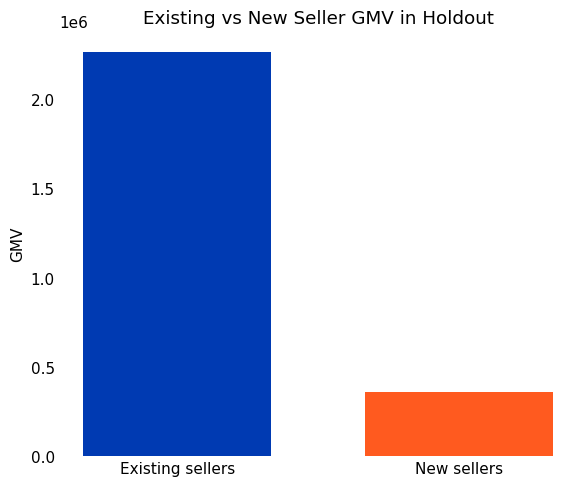

New seller GMV share: 13.7%


In [59]:
# ============================================================
# EXISTING VS NEW SELLER GMV
# ============================================================

plot_df = coverage_report.copy()

existing_gmv = plot_df["existing_holdout_gmv"].iloc[0]
new_gmv = plot_df["new_holdout_gmv"].iloc[0]

labels = ["Existing sellers", "New sellers"]
values = [existing_gmv, new_gmv]

# ------------------------------------------------------------
# CONTROL BAR WIDTH + GAP
# gap = 1/2 bar width
# ------------------------------------------------------------

bar_width = 0.8
gap = bar_width / 2

x = [0, bar_width + gap]

# custom colors
colors = ["#003AB2", "#FF5A1F"]

fig, ax = plt.subplots(figsize=(6, 5))

ax.bar(
    x,
    values,
    width=bar_width,
    color=colors
)

# ------------------------------------------------------------
# CLEAN VISUALIZATION
# - no grid
# - no border lines
# ------------------------------------------------------------

ax.grid(False)

for spine in ax.spines.values():
    spine.set_visible(False)

# remove tick marks
ax.tick_params(axis='both', length=0)

# labels
ax.set_xticks(x)
ax.set_xticklabels(labels)

ax.set_title("Existing vs New Seller GMV in Holdout")
ax.set_ylabel("GMV")

plt.tight_layout()
plt.show()

print(
    "New seller GMV share:",
    percent_format(new_gmv / (existing_gmv + new_gmv))
)

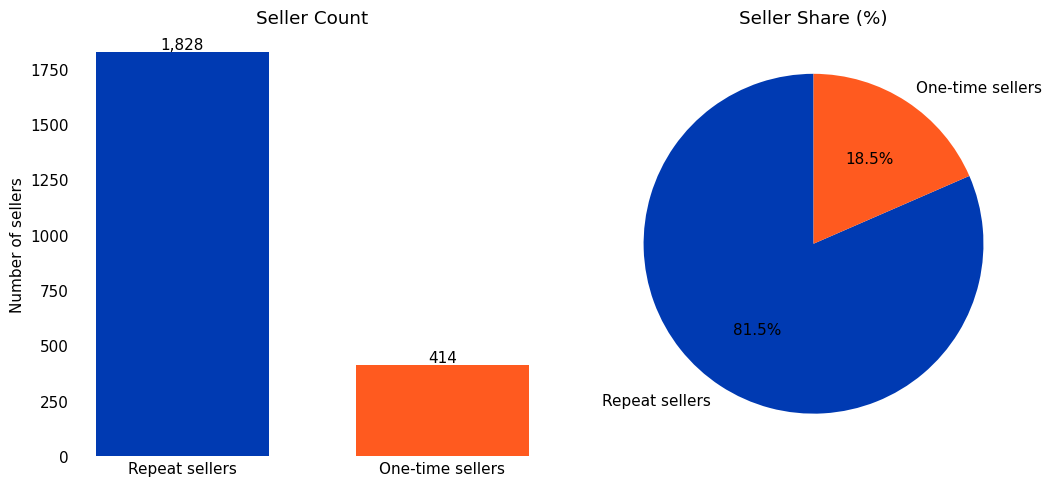

,seller_count
Repeat sellers,1828
One-time sellers,414


In [57]:
# ============================================================
# REPEAT VS ONE-TIME SELLERS
# ============================================================

repeat_counts = pd.Series({
    "Repeat sellers": (summary["frequency"] > 0).sum(),
    "One-time sellers": (summary["frequency"] == 0).sum()
})

labels = repeat_counts.index.tolist()
values = repeat_counts.values.tolist()

# custom colors
colors = ["#003AB2", "#FF5A1F"]

# ------------------------------------------------------------
# CREATE 2 PLOTS SIDE BY SIDE
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1, 2,
    figsize=(11, 5)
)

# ============================================================
# BAR CHART
# ============================================================

ax = axes[0]

bar_width = 0.8
gap = bar_width / 2

x = [0, bar_width + gap]

bars = ax.bar(
    x,
    values,
    width=bar_width,
    color=colors
)

# value labels
for bar in bars:
    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:,}",
        ha="center",
        va="bottom",
        fontsize=11
    )

# clean style
ax.grid(False)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(axis='both', length=0)

ax.set_xticks(x)
ax.set_xticklabels(labels)

ax.set_ylabel("Number of sellers")
ax.set_title("Seller Count")

# ============================================================
# PIE CHART
# ============================================================

ax2 = axes[1]

wedges, texts, autotexts = ax2.pie(
    values,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    wedgeprops={
        "linewidth": 0
    }
)

# improve percentage text size
for autotext in autotexts:
    autotext.set_fontsize(11)

ax2.set_title("Seller Share (%)")

plt.tight_layout()
plt.show()

display(repeat_counts.to_frame("seller_count"))

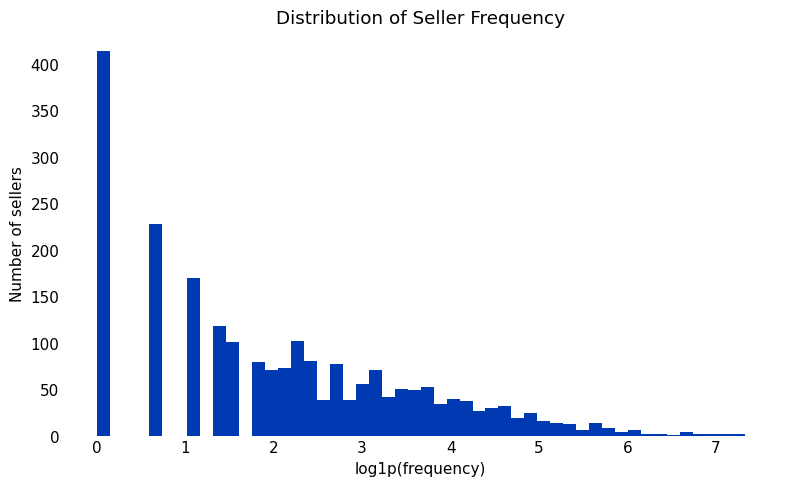

count    2242.000000
mean       30.892507
std        95.224794
min         0.000000
25%         1.000000
50%         6.000000
75%        23.000000
90%        70.000000
95%       128.000000
99%       398.470000
max      1515.000000
Name: frequency, dtype: float64

In [60]:
# ============================================================
# FREQUENCY DISTRIBUTION
# ============================================================

summary_plot = summary.copy()
summary_plot["log_frequency"] = np.log1p(summary_plot["frequency"])

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    summary_plot["log_frequency"],
    bins=50,
    color="#003AB2"
)

# ------------------------------------------------------------
# CLEAN VISUALIZATION
# ------------------------------------------------------------

ax.grid(False)

for spine in ax.spines.values():
    spine.set_visible(False)

# remove tick marks
ax.tick_params(axis='both', length=0)

# labels
ax.set_title("Distribution of Seller Frequency")
ax.set_xlabel("log1p(frequency)")
ax.set_ylabel("Number of sellers")

plt.tight_layout()
plt.show()

display(
    summary["frequency"].describe(
        percentiles=[.25, .5, .75, .9, .95, .99]
    )
)

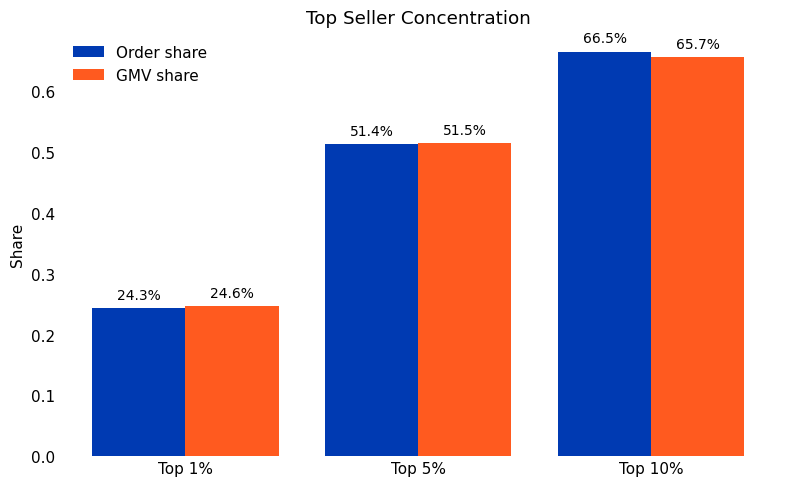

,top_percent,n_sellers,top_order_share,top_gmv_share,top_label
0,0.01,22,0.243360,0.246270,Top 1%
1,0.05,112,0.513769,0.515145,Top 5%
2,0.10,224,0.665469,0.656958,Top 10%


In [64]:
# ============================================================
# TOP SELLER CONCENTRATION
# ============================================================

plot_df = concentration_df.copy()

plot_df["top_label"] = (
    plot_df["top_percent"]
    .apply(lambda x: f"Top {int(x * 100)}%")
)

x = np.arange(len(plot_df))

# ------------------------------------------------------------
# CONTROL BAR WIDTH
# no gap between 2 bars in the same group
# ------------------------------------------------------------

bar_width = 0.4

# positions touch each other
left_pos = x - bar_width / 2
right_pos = x + bar_width / 2

# colors
colors = ["#003AB2", "#FF5A1F"]

fig, ax = plt.subplots(figsize=(8, 5))

# ============================================================
# ORDER SHARE
# ============================================================

bars1 = ax.bar(
    left_pos,
    plot_df["top_order_share"],
    width=bar_width,
    color=colors[0],
    label="Order share"
)

# ============================================================
# GMV SHARE
# ============================================================

bars2 = ax.bar(
    right_pos,
    plot_df["top_gmv_share"],
    width=bar_width,
    color=colors[1],
    label="GMV share"
)

# ------------------------------------------------------------
# VALUE LABELS
# ------------------------------------------------------------

for bars in [bars1, bars2]:

    for bar in bars:

        height = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.01,
            f"{height:.1%}",
            ha="center",
            va="bottom",
            fontsize=10
        )

# ------------------------------------------------------------
# CLEAN VISUALIZATION
# ------------------------------------------------------------

ax.grid(False)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(axis='both', length=0)

# labels
ax.set_xticks(x)
ax.set_xticklabels(plot_df["top_label"])

ax.set_ylabel("Share")
ax.set_title("Top Seller Concentration")

ax.legend(frameon=False)

plt.tight_layout()
plt.show()

display(plot_df)

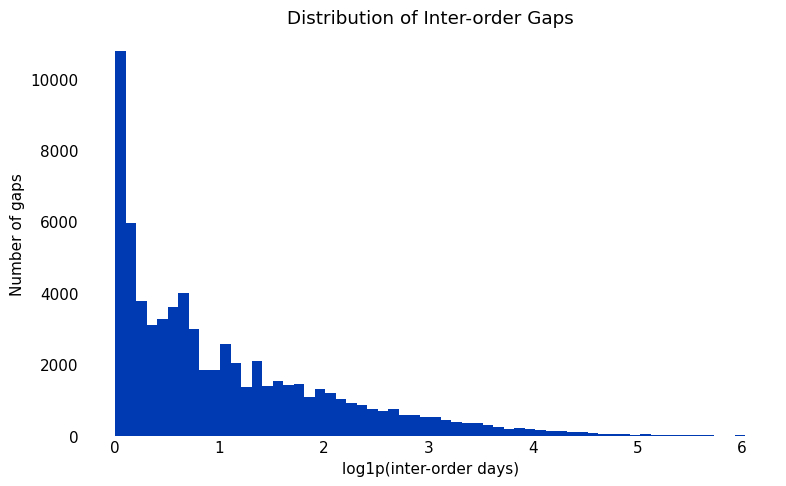

Median inter-order days: 1.0305671296296297
Share gaps < 1 day: 49.2%
Share gaps < 7 days: 83.9%


In [65]:
# ============================================================
# INTER-ORDER GAP DISTRIBUTION
# ============================================================

ipt_plot = ipt.copy()

ipt_plot["log_ipt_days"] = np.log1p(
    ipt_plot["ipt_days"]
)

# colors
hist_color = "#003AB2"

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    ipt_plot["log_ipt_days"],
    bins=60,
    color=hist_color
)

# ------------------------------------------------------------
# CLEAN VISUALIZATION
# ------------------------------------------------------------

ax.grid(False)

for spine in ax.spines.values():
    spine.set_visible(False)

# remove tick marks
ax.tick_params(axis='both', length=0)

# labels
ax.set_title("Distribution of Inter-order Gaps")
ax.set_xlabel("log1p(inter-order days)")
ax.set_ylabel("Number of gaps")

plt.tight_layout()
plt.show()

print(
    "Median inter-order days:",
    ipt_plot["ipt_days"].median()
)

print(
    "Share gaps < 1 day:",
    percent_format((ipt_plot["ipt_days"] < 1).mean())
)

print(
    "Share gaps < 7 days:",
    percent_format((ipt_plot["ipt_days"] < 7).mean())
)

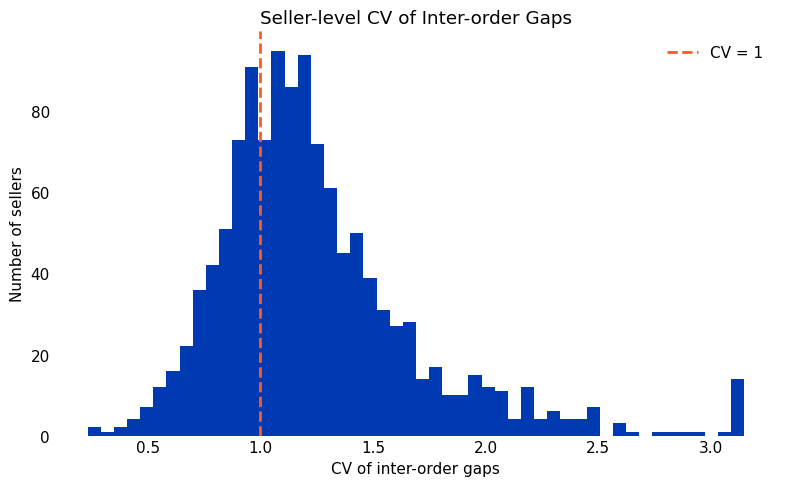

count    1213.000000
mean        1.252367
std         0.489482
min         0.233152
10%         0.789516
25%         0.961326
50%         1.160610
75%         1.422749
90%         1.810354
95%         2.123271
99%         3.148416
max         4.648733
Name: cv_gap, dtype: float64

In [66]:
# ============================================================
# CV OF INTER-ORDER GAPS
# ============================================================

fig, ax = plt.subplots(figsize=(8, 5))

cv_plot = gap_stats["cv_gap"].clip(
    upper=gap_stats["cv_gap"].quantile(.99)
)

# colors
hist_color = "#003AB2"
line_color = "#FF5A1F"

# histogram
ax.hist(
    cv_plot,
    bins=50,
    color=hist_color
)

# reference line
ax.axvline(
    1,
    linestyle="--",
    linewidth=2,
    color=line_color,
    label="CV = 1"
)

# ------------------------------------------------------------
# CLEAN VISUALIZATION
# ------------------------------------------------------------

ax.grid(False)

for spine in ax.spines.values():
    spine.set_visible(False)

# remove tick marks
ax.tick_params(axis='both', length=0)

# labels
ax.set_title("Seller-level CV of Inter-order Gaps")
ax.set_xlabel("CV of inter-order gaps")
ax.set_ylabel("Number of sellers")

# remove legend border
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

display(
    gap_stats["cv_gap"].describe(
        percentiles=[.1, .25, .5, .75, .9, .95, .99]
    )
)

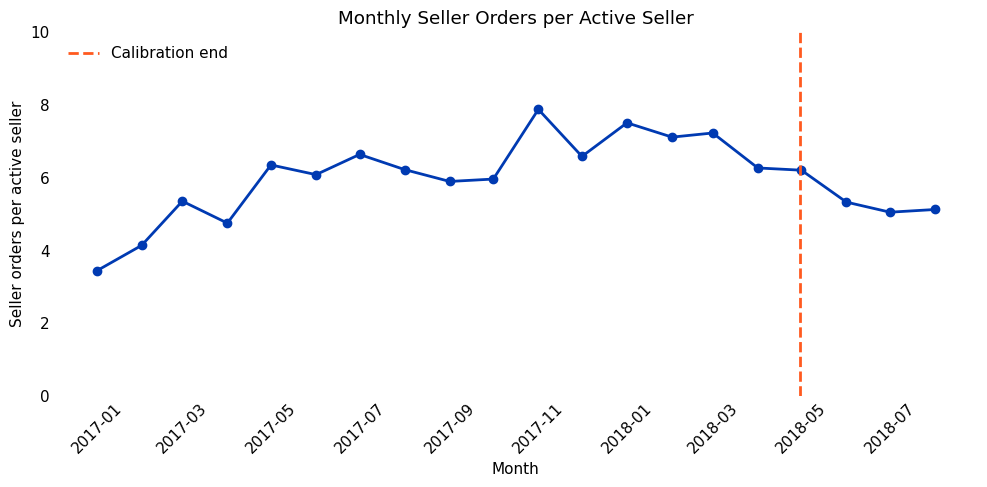

,month,seller_orders,marketplace_orders,active_sellers,gmv,seller_orders_per_active_seller
0,2017-01-01,754,750,219,111798.36,3.442922
1,2017-02-01,1666,1653,402,234223.40,4.144279
2,2017-03-01,2551,2546,476,359198.85,5.359244
3,2017-04-01,2321,2303,488,340669.68,4.756148
4,2017-05-01,3578,3546,563,489338.25,6.355240
5,2017-06-01,3160,3135,519,421923.37,6.088632
6,2017-07-01,3940,3872,593,481604.52,6.644182
7,2017-08-01,4253,4193,683,554699.70,6.226940
8,2017-09-01,4196,4150,711,607399.67,5.901547
9,2017-10-01,4547,4478,762,648247.65,5.967192


In [67]:
# ============================================================
# MONTHLY STATIONARITY
# ============================================================

monthly_plot = monthly.reset_index().copy()

# colors
line_color = "#003AB2"
ref_color = "#FF5A1F"

fig, ax = plt.subplots(figsize=(10, 5))

# ============================================================
# MAIN LINE
# ============================================================

ax.plot(
    monthly_plot["month"],
    monthly_plot["seller_orders_per_active_seller"],
    marker="o",
    linewidth=2,
    color=line_color
)

# ============================================================
# CALIBRATION END LINE
# ============================================================

ax.axvline(
    CALIBRATION_END,
    linestyle="--",
    linewidth=2,
    color=ref_color,
    label="Calibration end"
)

# ------------------------------------------------------------
# CLEAN VISUALIZATION
# ------------------------------------------------------------

ax.grid(False)

for spine in ax.spines.values():
    spine.set_visible(False)

# remove tick marks
ax.tick_params(axis='both', length=0)

# ------------------------------------------------------------
# FIX Y-AXIS RANGE
# ------------------------------------------------------------

ax.set_ylim(0, 10)

# labels
ax.set_title("Monthly Seller Orders per Active Seller")
ax.set_xlabel("Month")
ax.set_ylabel("Seller orders per active seller")

# remove legend border
ax.legend(frameon=False)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

display(monthly_plot)

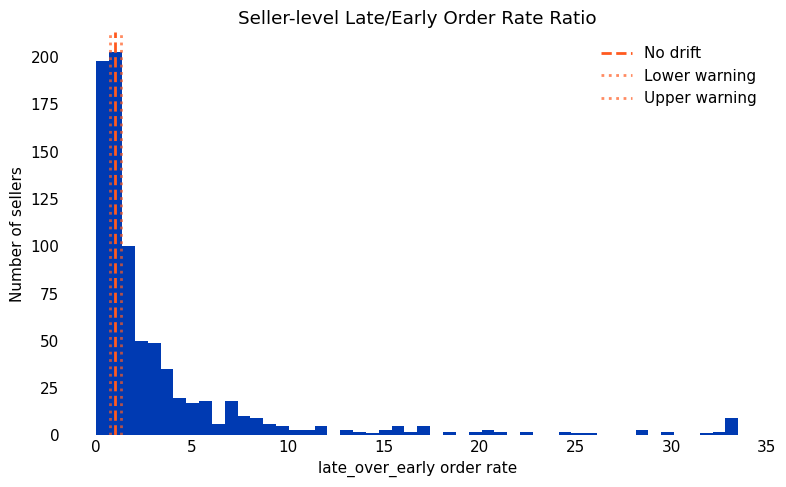

count    808.000000
mean       4.053720
std       13.044712
min        0.010129
10%        0.329184
25%        0.704256
50%        1.387061
75%        3.501890
90%        8.355786
95%       15.800830
99%       33.507635
max      317.004149
Name: late_over_early, dtype: float64

In [68]:
# ============================================================
# SELLER-LEVEL LATE/EARLY ORDER RATE DRIFT
# ============================================================

rate_plot = rate_compare.copy()

fig, ax = plt.subplots(figsize=(8, 5))

plot_values = rate_plot["late_over_early"].clip(
    upper=rate_plot["late_over_early"].quantile(.99)
)

# colors
hist_color = "#003AB2"
ref_color = "#FF5A1F"

# ============================================================
# HISTOGRAM
# ============================================================

ax.hist(
    plot_values,
    bins=50,
    color=hist_color
)

# ============================================================
# REFERENCE LINES
# ============================================================

ax.axvline(
    1,
    linestyle="--",
    linewidth=2,
    color=ref_color,
    label="No drift"
)

ax.axvline(
    0.7,
    linestyle=":",
    linewidth=2,
    color=ref_color,
    alpha=0.7,
    label="Lower warning"
)

ax.axvline(
    1.3,
    linestyle=":",
    linewidth=2,
    color=ref_color,
    alpha=0.7,
    label="Upper warning"
)

# ------------------------------------------------------------
# CLEAN VISUALIZATION
# ------------------------------------------------------------

ax.grid(False)

for spine in ax.spines.values():
    spine.set_visible(False)

# remove tick marks
ax.tick_params(axis='both', length=0)

# labels
ax.set_title("Seller-level Late/Early Order Rate Ratio")
ax.set_xlabel("late_over_early order rate")
ax.set_ylabel("Number of sellers")

# remove legend border
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

display(
    rate_plot["late_over_early"].describe(
        percentiles=[.1, .25, .5, .75, .9, .95, .99]
    )
)

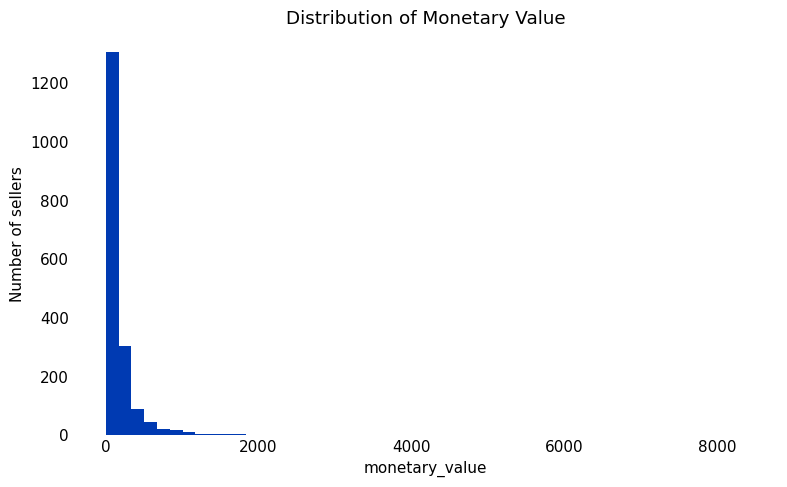

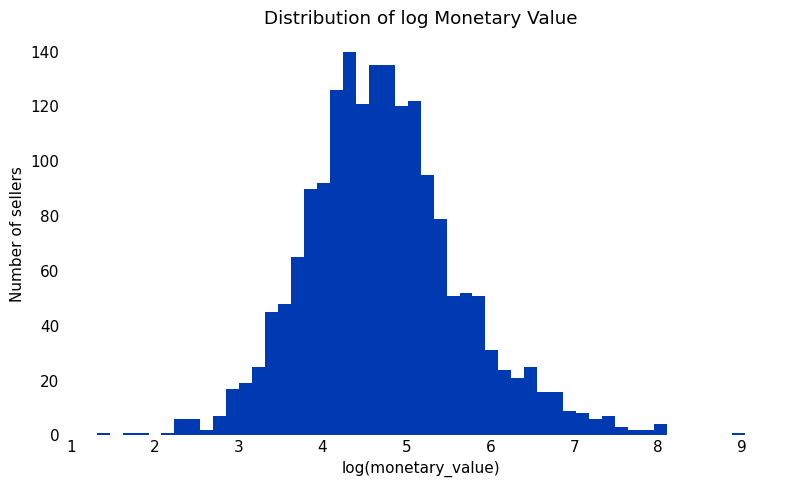

count    1828.000000
mean      190.603386
std       340.701343
min         3.695000
25%        61.047531
50%       106.376515
75%       189.168929
90%       373.429047
95%       640.521534
99%      1554.360000
max      8370.000000
Name: monetary_value, dtype: float64

In [69]:
# ============================================================
# MONETARY VALUE DISTRIBUTION
# ============================================================

gg_plot = gg_data.copy()

# colors
hist_color = "#003AB2"

# ============================================================
# RAW MONETARY VALUE DISTRIBUTION
# ============================================================

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    gg_plot["monetary_value"],
    bins=50,
    color=hist_color
)

# ------------------------------------------------------------
# CLEAN VISUALIZATION
# ------------------------------------------------------------

ax.grid(False)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(axis='both', length=0)

# labels
ax.set_title("Distribution of Monetary Value")
ax.set_xlabel("monetary_value")
ax.set_ylabel("Number of sellers")

plt.tight_layout()
plt.show()

# ============================================================
# LOG MONETARY VALUE DISTRIBUTION
# ============================================================

gg_plot["log_monetary_value"] = np.log(
    gg_plot["monetary_value"]
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    gg_plot["log_monetary_value"],
    bins=50,
    color=hist_color
)

# ------------------------------------------------------------
# CLEAN VISUALIZATION
# ------------------------------------------------------------

ax.grid(False)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(axis='both', length=0)

# labels
ax.set_title("Distribution of log Monetary Value")
ax.set_xlabel("log(monetary_value)")
ax.set_ylabel("Number of sellers")

plt.tight_layout()
plt.show()

display(
    gg_plot["monetary_value"].describe(
        percentiles=[.25, .5, .75, .9, .95, .99]
    )
)

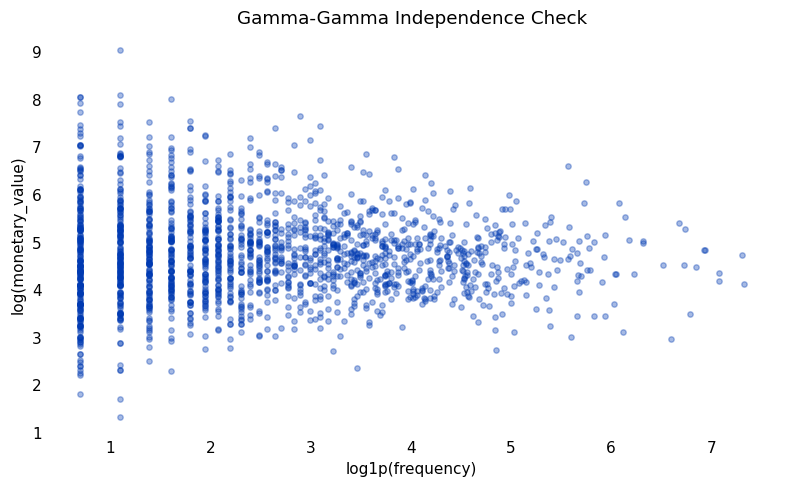

Pearson corr: -0.062481107658446645
Spearman corr: 0.004956098071262387


In [70]:
# ============================================================
# FREQUENCY VS MONETARY INDEPENDENCE
# ============================================================

gg_plot["log_frequency"] = np.log1p(
    gg_plot["frequency"]
)

fig, ax = plt.subplots(figsize=(8, 5))

# colors
point_color = "#003AB2"

# ============================================================
# SCATTER PLOT
# ============================================================

ax.scatter(
    gg_plot["log_frequency"],
    gg_plot["log_monetary_value"],
    alpha=0.35,
    s=15,
    color=point_color
)

# ------------------------------------------------------------
# CLEAN VISUALIZATION
# ------------------------------------------------------------

ax.grid(False)

for spine in ax.spines.values():
    spine.set_visible(False)

# remove tick marks
ax.tick_params(axis='both', length=0)

# labels
ax.set_title("Gamma-Gamma Independence Check")
ax.set_xlabel("log1p(frequency)")
ax.set_ylabel("log(monetary_value)")

plt.tight_layout()
plt.show()

print(
    "Pearson corr:",
    gg_plot[
        ["frequency", "monetary_value"]
    ].corr(method="pearson").iloc[0, 1]
)

print(
    "Spearman corr:",
    gg_plot[
        ["frequency", "monetary_value"]
    ].corr(method="spearman").iloc[0, 1]
)

,frequency,recency,T,monetary_value
frequency,1.000000,0.724183,0.394601,0.004956
recency,0.724183,1.000000,0.681448,0.054145
T,0.394601,0.681448,1.000000,-0.003050
monetary_value,0.004956,0.054145,-0.003050,1.000000


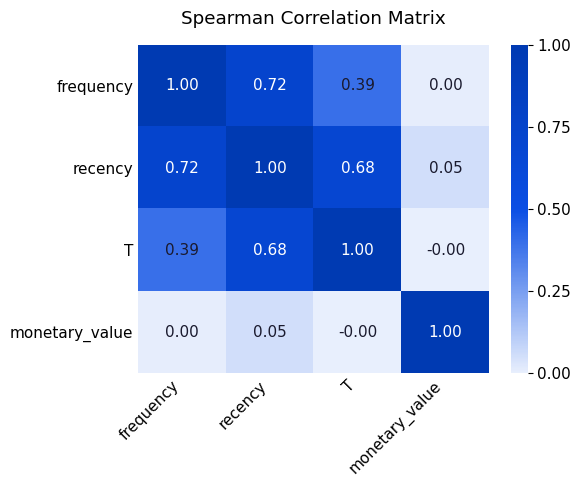

In [75]:
# ============================================================
# EXTENDED CORRELATION HEATMAP
# ============================================================

from matplotlib.colors import LinearSegmentedColormap

corr_vars = [
    "frequency",
    "recency",
    "T",
    "monetary_value"
]

corr_matrix = gg_plot[corr_vars].corr(
    method="spearman"
)

display(corr_matrix)

# ============================================================
# BRAND COLORS
# ============================================================

olist_blue = "#0A4EE4"
blue_dark = "#003AB2"
blue_tint = "#E8EFFD"

olist_dark = "#1A1A2E"

# ============================================================
# CUSTOM BRAND COLORMAP
# ============================================================

brand_cmap = LinearSegmentedColormap.from_list(
    "olist_brand",
    [
        blue_tint,
        olist_blue,
        blue_dark
    ]
)

# ============================================================
# HEATMAP
# ============================================================

fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(
    corr_matrix.values,
    aspect="auto",
    cmap=brand_cmap,
    vmin=0,
    vmax=1
)

# ticks
ax.set_xticks(np.arange(len(corr_vars)))
ax.set_yticks(np.arange(len(corr_vars)))

ax.set_xticklabels(
    corr_vars,
    rotation=45,
    ha="right"
)

ax.set_yticklabels(corr_vars)

# ============================================================
# CELL LABELS
# ============================================================

for i in range(len(corr_vars)):
    for j in range(len(corr_vars)):

        value = corr_matrix.values[i, j]

        ax.text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=11,
            color="white" if value > 0.55 else olist_dark
        )

# ------------------------------------------------------------
# CLEAN VISUALIZATION
# ------------------------------------------------------------

ax.grid(False)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(axis='both', length=0)

# title
ax.set_title(
    "Spearman Correlation Matrix",
    pad=15
)

# ============================================================
# COLORBAR
# ============================================================

cbar = fig.colorbar(im, ax=ax)

cbar.outline.set_visible(False)

cbar.set_ticks([0, 0.25, 0.5, 0.75, 1])

plt.tight_layout()
plt.show()

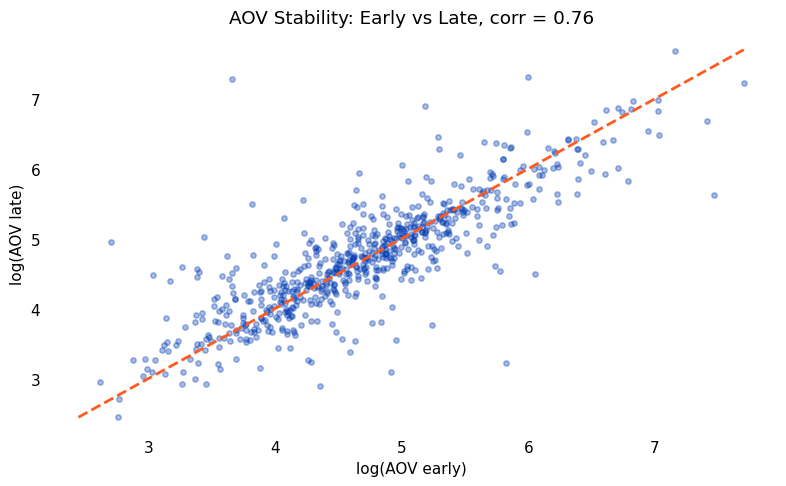

In [74]:
# ============================================================
# AOV EARLY VS LATE STABILITY
# ============================================================

aov_plot = aov_stability.copy()

aov_plot["log_aov_early"] = np.log(
    aov_plot["aov_early"]
)

aov_plot["log_aov_late"] = np.log(
    aov_plot["aov_late"]
)

aov_corr = aov_plot[
    ["aov_early", "aov_late"]
].corr().iloc[0, 1]

# colors
point_color = "#003AB2"
line_color = "#FF5A1F"

fig, ax = plt.subplots(figsize=(8, 5))

# ============================================================
# SCATTER PLOT
# ============================================================

ax.scatter(
    aov_plot["log_aov_early"],
    aov_plot["log_aov_late"],
    alpha=0.35,
    s=15,
    color=point_color
)

# ============================================================
# REFERENCE LINE (y = x)
# ============================================================

min_axis = min(
    aov_plot["log_aov_early"].min(),
    aov_plot["log_aov_late"].min()
)

max_axis = max(
    aov_plot["log_aov_early"].max(),
    aov_plot["log_aov_late"].max()
)

ax.plot(
    [min_axis, max_axis],
    [min_axis, max_axis],
    linestyle="--",
    linewidth=2,
    color=line_color
)

# ------------------------------------------------------------
# CLEAN VISUALIZATION
# ------------------------------------------------------------

ax.grid(False)

for spine in ax.spines.values():
    spine.set_visible(False)

# remove tick marks
ax.tick_params(axis='both', length=0)

# labels
ax.set_title(
    f"AOV Stability: Early vs Late, corr = {aov_corr:.2f}"
)

ax.set_xlabel("log(AOV early)")
ax.set_ylabel("log(AOV late)")

plt.tight_layout()
plt.show()